# 01 - Data Exploration & Descriptive Statistics

**Primary**: Naman Sudan  
**Dataset**: Starbucks Customer Ordering Patterns (100K orders)

This notebook covers:
- Loading and inspecting the dataset
- Variable type classification
- Descriptive statistics (mean, median, mode, SD, variance, five-number summary, IQR)
- Outlier detection using IQR method
- Visualizations (histograms, box plots, bar charts, scatter plots, heatmaps)

**Course references**: Lecture 1 (Measures of Central Tendency & Dispersion), Lecture 2 (Variable Types & Graphical Summary)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load the Dataset

In [2]:
df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Unique customers: {df["customer_id"].nunique()}')
print(f'Unique stores: {df["store_id"].nunique()}')
print(f'Date range: {df["order_date"].min()} to {df["order_date"].max()}')
print(f'\nMissing values:\n{df.isnull().sum().sum()} total')

Dataset shape: 100000 rows, 20 columns
Unique customers: 14988
Unique stores: 500
Date range: 2024-01-01 to 2025-12-30

Missing values:
0 total


In [3]:
df.head(10)

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3
5,CUST_04338,ORD_00000006,2025-08-30,11:41,Sat,Mobile App,STR_497,Rural,Northeast,45-54,Male,True,5,1,21.13,5.0,Brewed Coffee,True,False,4
6,CUST_11185,ORD_00000007,2025-10-05,06:55,Sun,Mobile App,STR_238,Suburban,Midwest,25-34,Prefer not to say,True,3,0,12.95,4.2,Espresso,False,True,3
7,CUST_00361,ORD_00000008,2025-12-17,19:08,Wed,Mobile App,STR_150,Urban,Southwest,18-24,Prefer not to say,True,5,6,26.33,5.0,Brewed Coffee,True,False,5
8,CUST_13235,ORD_00000009,2024-02-03,06:44,Sat,Mobile App,STR_466,Rural,Southwest,45-54,Female,True,2,2,12.17,3.9,Frappuccino,False,True,5
9,CUST_08695,ORD_00000010,2025-05-12,12:28,Mon,In-Store Cashier,STR_148,Urban,Midwest,55+,Male,True,3,1,11.11,4.3,Refresher,False,False,5


In [4]:
df.dtypes

customer_id                  str
order_id                     str
order_date                   str
order_time                   str
day_of_week                  str
order_channel                str
store_id                     str
store_location_type          str
region                       str
customer_age_group           str
customer_gender              str
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category               str
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64
dtype: object

## 2. Variable Classification

Classifying each variable by type (Lecture 2):

| Variable | Type | Scale |
|----------|------|-------|
| customer_id | Qualitative | Nominal |
| order_id | Qualitative | Nominal |
| order_date | Quantitative | Interval |
| order_time | Quantitative | Interval |
| day_of_week | Qualitative | Ordinal |
| order_channel | Qualitative | Nominal |
| store_id | Qualitative | Nominal |
| store_location_type | Qualitative | Nominal |
| region | Qualitative | Nominal |
| customer_age_group | Qualitative | Ordinal |
| customer_gender | Qualitative | Nominal |
| is_rewards_member | Qualitative | Nominal (binary) |
| cart_size | Quantitative | Discrete |
| num_customizations | Quantitative | Discrete |
| total_spend | Quantitative | Continuous (ratio) |
| fulfillment_time_min | Quantitative | Continuous (ratio) |
| drink_category | Qualitative | Nominal |
| has_food_item | Qualitative | Nominal (binary) |
| order_ahead | Qualitative | Nominal (binary) |
| customer_satisfaction | Quantitative | Ordinal/Discrete |

## 3. Descriptive Statistics

Computing measures of central tendency and dispersion (Lecture 1).

In [5]:
# Numerical columns for analysis
numerical_cols = ['total_spend', 'cart_size', 'num_customizations', 'fulfillment_time_min', 'customer_satisfaction']

# Central tendency and dispersion
desc_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Std Dev': df[numerical_cols].std(),
    'Variance': df[numerical_cols].var(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max(),
    'Range': df[numerical_cols].max() - df[numerical_cols].min()
}).round(3)

desc_stats

,Mean,Median,Mode,Std Dev,Variance,Min,Max,Range
total_spend,14.867,14.17,12.04,5.507,30.325,3.51,40.31,36.8
cart_size,3.742,4.00,3.00,1.698,2.883,1.00,10.00,9.0
num_customizations,1.811,2.00,1.00,1.463,2.140,0.00,8.00,8.0
fulfillment_time_min,4.546,4.40,4.30,1.550,2.403,1.00,11.20,10.2
customer_satisfaction,3.688,4.00,4.00,1.184,1.402,1.00,5.00,4.0


### Five-Number Summary and IQR

In [6]:
five_num = pd.DataFrame({
    'Min': df[numerical_cols].min(),
    'Q1': df[numerical_cols].quantile(0.25),
    'Median': df[numerical_cols].median(),
    'Q3': df[numerical_cols].quantile(0.75),
    'Max': df[numerical_cols].max(),
    'IQR': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
}).round(3)

five_num

,Min,Q1,Median,Q3,Max,IQR
total_spend,3.51,10.838,14.17,18.18,40.31,7.342
cart_size,1.00,3.000,4.00,5.00,10.00,2.000
num_customizations,0.00,1.000,2.00,3.00,8.00,2.000
fulfillment_time_min,1.00,3.400,4.40,5.50,11.20,2.100
customer_satisfaction,1.00,3.000,4.00,5.00,5.00,2.000


### Outlier Detection (IQR Method)

An observation is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

In [7]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%) | Fences: [{lower_fence:.2f}, {upper_fence:.2f}]')

total_spend: 1415 outliers (1.42%) | Fences: [-0.18, 29.19]
cart_size: 900 outliers (0.90%) | Fences: [0.00, 8.00]
num_customizations: 609 outliers (0.61%) | Fences: [-2.00, 6.00]
fulfillment_time_min: 811 outliers (0.81%) | Fences: [0.25, 8.65]
customer_satisfaction: 0 outliers (0.00%) | Fences: [0.00, 8.00]


## 4. Categorical Variable Breakdown

In [8]:
categorical_cols = ['order_channel', 'store_location_type', 'region', 'customer_age_group',
                    'customer_gender', 'drink_category', 'is_rewards_member', 'has_food_item', 'order_ahead']

for col in categorical_cols:
    print(f'\n--- {col} ---')
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage': pcts.round(2)})
    print(summary.to_string())


--- order_channel ---
                  Count  Percentage
order_channel                      
Mobile App        42521       42.52
Drive-Thru        27996       28.00
In-Store Cashier  22063       22.06
Kiosk              7420        7.42

--- store_location_type ---
                     Count  Percentage
store_location_type                   
Suburban             35696       35.70
Urban                32584       32.58
Rural                31720       31.72

--- region ---
           Count  Percentage
region                      
West       22608       22.61
Southeast  20223       20.22
Southwest  19663       19.66
Midwest    19470       19.47
Northeast  18036       18.04

--- customer_age_group ---
                    Count  Percentage
customer_age_group                   
25-34               29782       29.78
35-44               24543       24.54
18-24               20274       20.27
45-54               15382       15.38
55+                 10019       10.02

--- customer_gender ---

## 5. Visualizations

### 5a. Spending Distribution (Histogram)

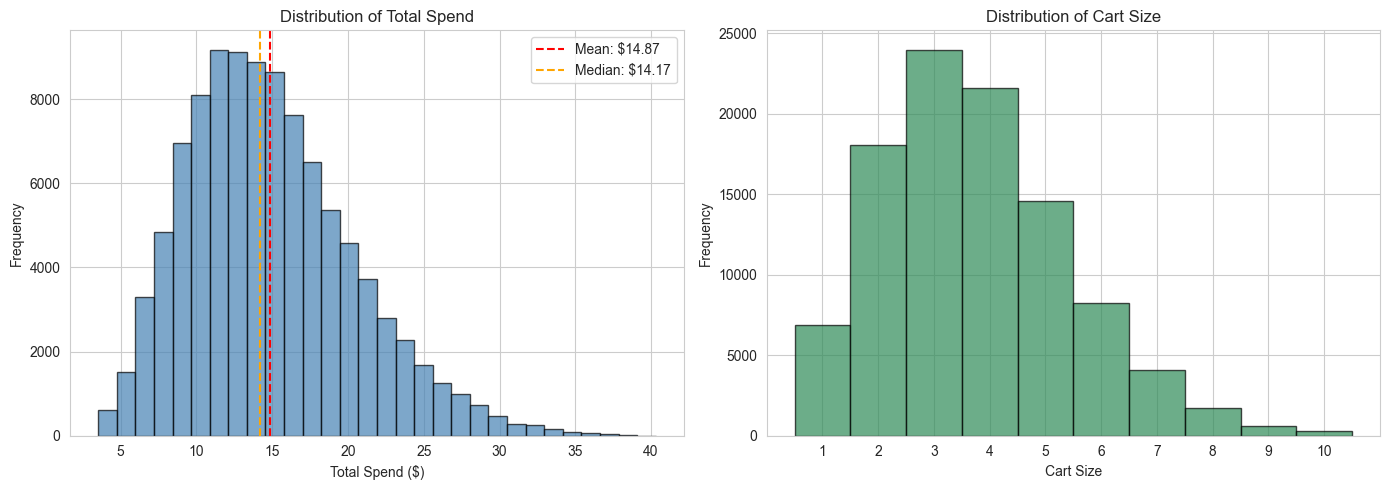

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of total_spend
axes[0].hist(df['total_spend'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['total_spend'].mean(), color='red', linestyle='--', label=f'Mean: ${df["total_spend"].mean():.2f}')
axes[0].axvline(df['total_spend'].median(), color='orange', linestyle='--', label=f'Median: ${df["total_spend"].median():.2f}')
axes[0].set_xlabel('Total Spend ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Spend')
axes[0].legend()

# Histogram of cart_size
axes[1].hist(df['cart_size'], bins=range(1, 12), edgecolor='black', alpha=0.7, color='seagreen', align='left')
axes[1].set_xlabel('Cart Size')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Cart Size')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

### 5b. Box Plots by Category

/var/folders/7g/cm89ydgs6sx0s24lwrrrjglc0000gn/T/ipykernel_38116/3776496596.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Member', 'Member'])


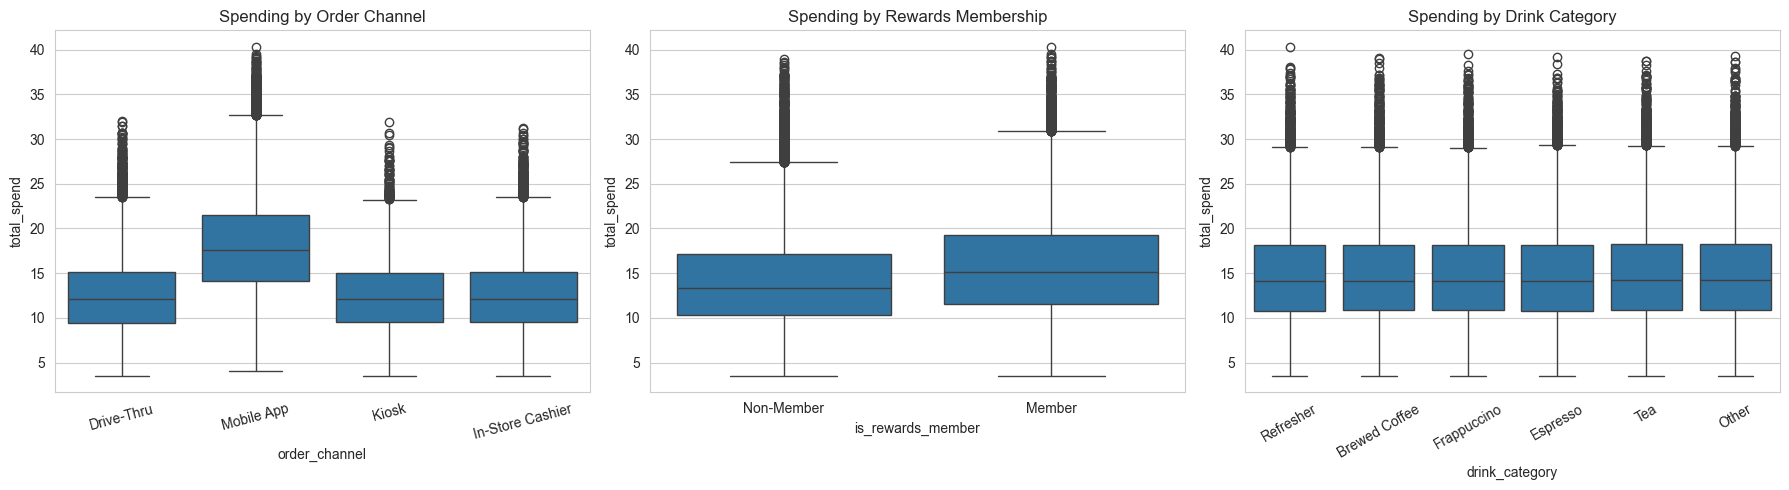

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='order_channel', y='total_spend', ax=axes[0])
axes[0].set_title('Spending by Order Channel')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='is_rewards_member', y='total_spend', ax=axes[1])
axes[1].set_title('Spending by Rewards Membership')
axes[1].set_xticklabels(['Non-Member', 'Member'])

sns.boxplot(data=df, x='drink_category', y='total_spend', ax=axes[2])
axes[2].set_title('Spending by Drink Category')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5c. Bar Charts (Category Frequencies)

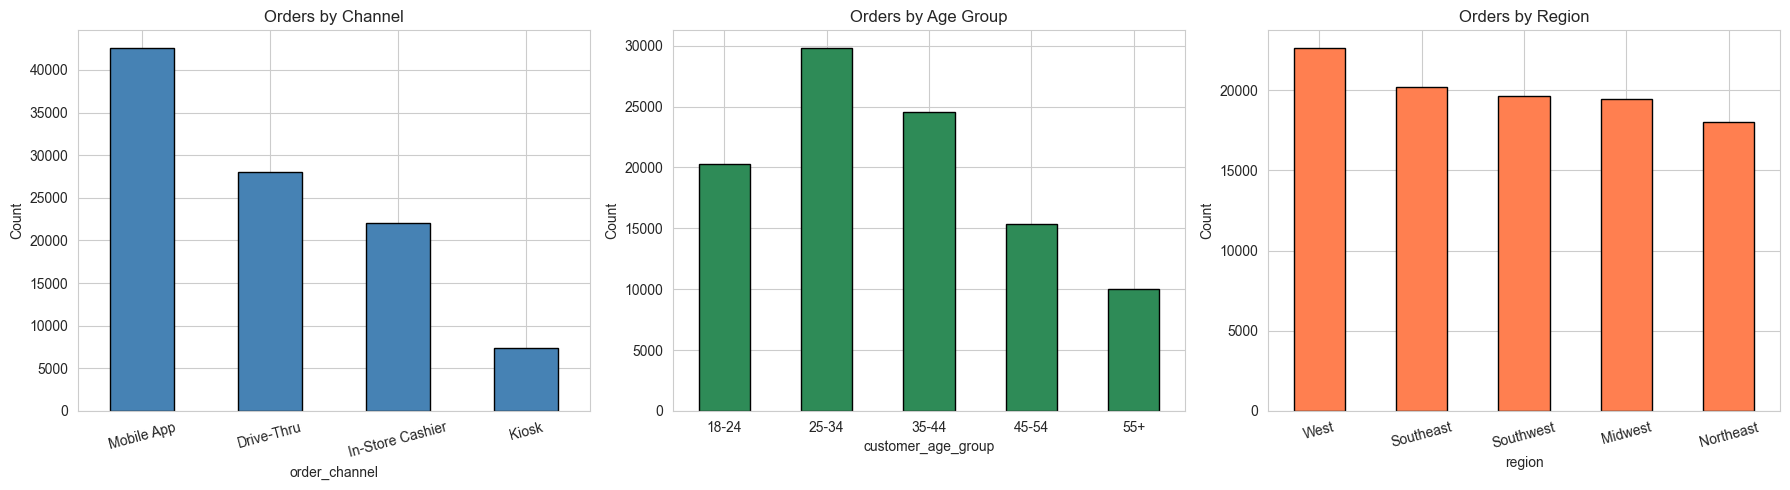

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['order_channel'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Orders by Channel')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

df['customer_age_group'].value_counts().reindex(['18-24', '25-34', '35-44', '45-54', '55+']).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Orders by Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

df['region'].value_counts().plot(kind='bar', ax=axes[2], color='coral', edgecolor='black')
axes[2].set_title('Orders by Region')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 5d. Scatter Plots

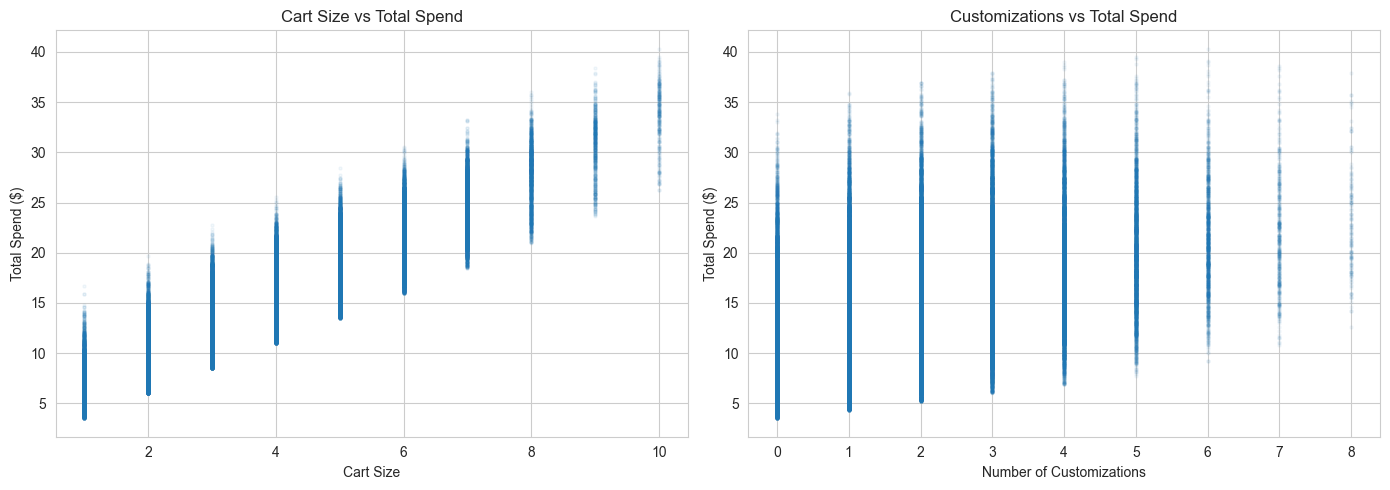

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['cart_size'], df['total_spend'], alpha=0.05, s=5)
axes[0].set_xlabel('Cart Size')
axes[0].set_ylabel('Total Spend ($)')
axes[0].set_title('Cart Size vs Total Spend')

axes[1].scatter(df['num_customizations'], df['total_spend'], alpha=0.05, s=5)
axes[1].set_xlabel('Number of Customizations')
axes[1].set_ylabel('Total Spend ($)')
axes[1].set_title('Customizations vs Total Spend')

plt.tight_layout()
plt.show()

### 5e. Correlation Heatmap (preview for Notebook 02)

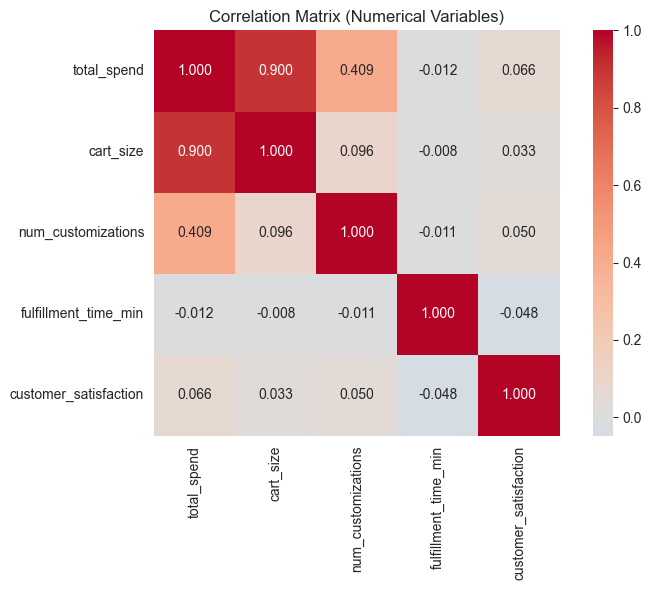

In [13]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix (Numerical Variables)')
plt.tight_layout()
plt.show()

### 5f. Mean Spend by Segment

In [14]:
segments = ['order_channel', 'is_rewards_member', 'store_location_type', 'customer_age_group', 'drink_category']

for seg in segments:
    group_stats = df.groupby(seg)['total_spend'].agg(['mean', 'std', 'count']).round(2)
    group_stats.columns = ['Mean Spend', 'Std Dev', 'Count']
    print(f'\n--- Total Spend by {seg} ---')
    print(group_stats.to_string())


--- Total Spend by order_channel ---
                  Mean Spend  Std Dev  Count
order_channel                               
Drive-Thru             12.48     4.16  27996
In-Store Cashier       12.51     4.16  22063
Kiosk                  12.49     4.13   7420
Mobile App             18.08     5.48  42521

--- Total Spend by is_rewards_member ---
                   Mean Spend  Std Dev  Count
is_rewards_member                            
False                   14.09     5.23  52283
True                    15.72     5.67  47717

--- Total Spend by store_location_type ---
                     Mean Spend  Std Dev  Count
store_location_type                            
Rural                     14.88     5.52  31720
Suburban                  14.90     5.49  35696
Urban                     14.81     5.51  32584

--- Total Spend by customer_age_group ---
                    Mean Spend  Std Dev  Count
customer_age_group                            
18-24                    15.55     5.68  2027

## 6. Key Observations

From the exploration above:

- Mobile App orders have a noticeably higher mean spend ($18.08) compared to the other three channels which are all around $12.50. This is the strongest spending difference in the dataset and worth investigating further with hypothesis testing.
- Rewards members spend about $1.60 more on average than non-members ($15.72 vs $14.09). Statistically significant? We will test this in notebook 03.
- Younger age groups (18-34) tend to spend more than older groups. The 55+ group has the lowest mean spend at $13.06.
- Drink category has almost no effect on total spend. All six categories land between $14.82 and $14.91.
- Store location type (Urban/Suburban/Rural) also shows minimal spending differences.
- The spending distribution looks roughly symmetric with a slight right skew. Mean ($14.87) is close to median ($14.17).
- Outlier rates are low across all variables (under 1.5%). No major data quality issues.
- About 42.5% of orders come through the Mobile App, making it the dominant channel.
- The correlation heatmap shows cart_size has the strongest relationship with total_spend. We will quantify this in notebook 02.